# 01 — EDA completo (Issue #17) — Telco Churn

Notebook de Análise Exploratória de Dados para o dataset **Telco Customer Churn**.

Estrutura de EDA completa adaptada para as features de churn do projeto.

## 1. Configuração do ambiente

In [1]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

try:
    import seaborn as sns

    sns.set_style("whitegrid")
except Exception:
    sns = None

plt.rcParams["figure.figsize"] = (12, 6)

## 2. Carregamento dos dados

Caminho no mesmo padrão da aula (relativo ao diretório `notebooks/`):
- `../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv`

In [2]:
path = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(path)

print(f"Shape dos dados: {df.shape}")
print("\nPrimeiras linhas:")
df.head()

Shape dos dados: (7043, 21)

Primeiras linhas:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("=== INFORMAÇÕES GERAIS ===\n")
print(df.info())

print("\n=== ESTATÍSTICAS DESCRITIVAS (NUMÉRICAS) ===\n")
df.describe()

=== INFORMAÇÕES GERAIS ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilli

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
# Preparação mínima para EDA
df_eda = df.copy()
df_eda["TotalCharges"] = pd.to_numeric(df_eda["TotalCharges"], errors="coerce")
df_eda["Churn_bin"] = (df_eda["Churn"] == "Yes").astype(int)

print("Conversão concluída:")
print("- TotalCharges numérico com NaN para vazios")
print("- Churn_bin criado (Yes=1, No=0)")

Conversão concluída:
- TotalCharges numérico com NaN para vazios
- Churn_bin criado (Yes=1, No=0)


## 3. Análise Exploratória de Dados (EDA)

### 3.1 Análise de Missing Values

=== ANÁLISE DE MISSING VALUES ===



,Coluna,Missing_Count,Missing_Percentage
TotalCharges,TotalCharges,11,0.16


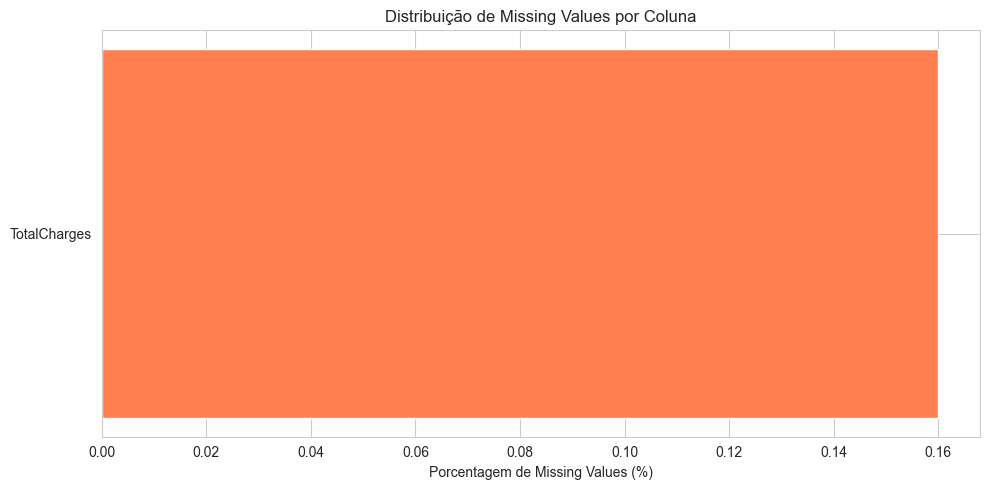

In [5]:
print("=== ANÁLISE DE MISSING VALUES ===\n")

missing_values = pd.DataFrame(
    {
        "Coluna": df_eda.columns,
        "Missing_Count": df_eda.isnull().sum(),
        "Missing_Percentage": (
            df_eda.isnull().sum() / len(df_eda) * 100
        ).round(2),
    }
)

missing_values = missing_values[
    missing_values["Missing_Count"] > 0
].sort_values(by="Missing_Percentage", ascending=False)

if len(missing_values) > 0:
    display(missing_values)

    plt.figure(figsize=(10, 5))
    plt.barh(
        missing_values["Coluna"],
        missing_values["Missing_Percentage"],
        color="coral",
    )
    plt.xlabel("Porcentagem de Missing Values (%)")
    plt.title("Distribuição de Missing Values por Coluna")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum missing value detectado!")

### 3.2 Análise da variável target (`Churn`)

=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===

Contagem:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentual:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


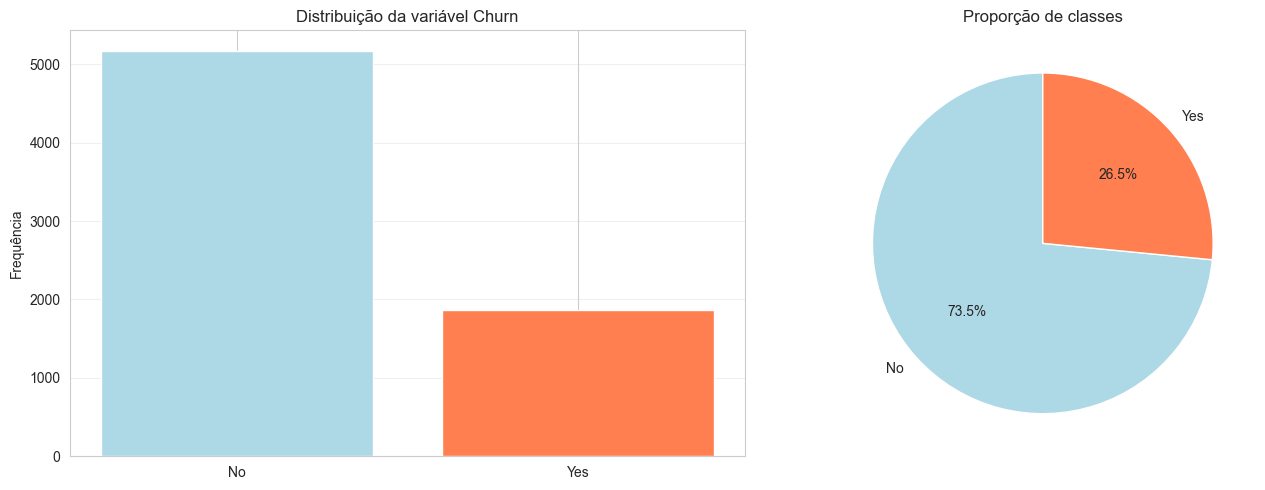


Ratio de balanceamento: 0.36
⚠️ Dataset desbalanceado: considerar class_weight/SMOTE em modelagem.


In [6]:
print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===\n")
target_counts = df_eda["Churn"].value_counts()
target_percentages = (
    df_eda["Churn"].value_counts(normalize=True) * 100
).round(2)

print("Contagem:")
print(target_counts)
print("\nPercentual:")
print(target_percentages)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    target_counts.index, target_counts.values, color=["lightblue", "coral"]
)
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição da variável Churn")
axes[0].grid(axis="y", alpha=0.3)

axes[1].pie(
    target_counts.values,
    labels=target_counts.index,
    autopct="%1.1f%%",
    colors=["lightblue", "coral"],
    startangle=90,
)
axes[1].set_title("Proporção de classes")

plt.tight_layout()
plt.show()

ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print(
        "⚠️ Dataset desbalanceado: considerar class_weight/SMOTE em modelagem."
    )
else:
    print("✓ Dataset razoavelmente balanceado.")

### 3.3 Análise de Outliers

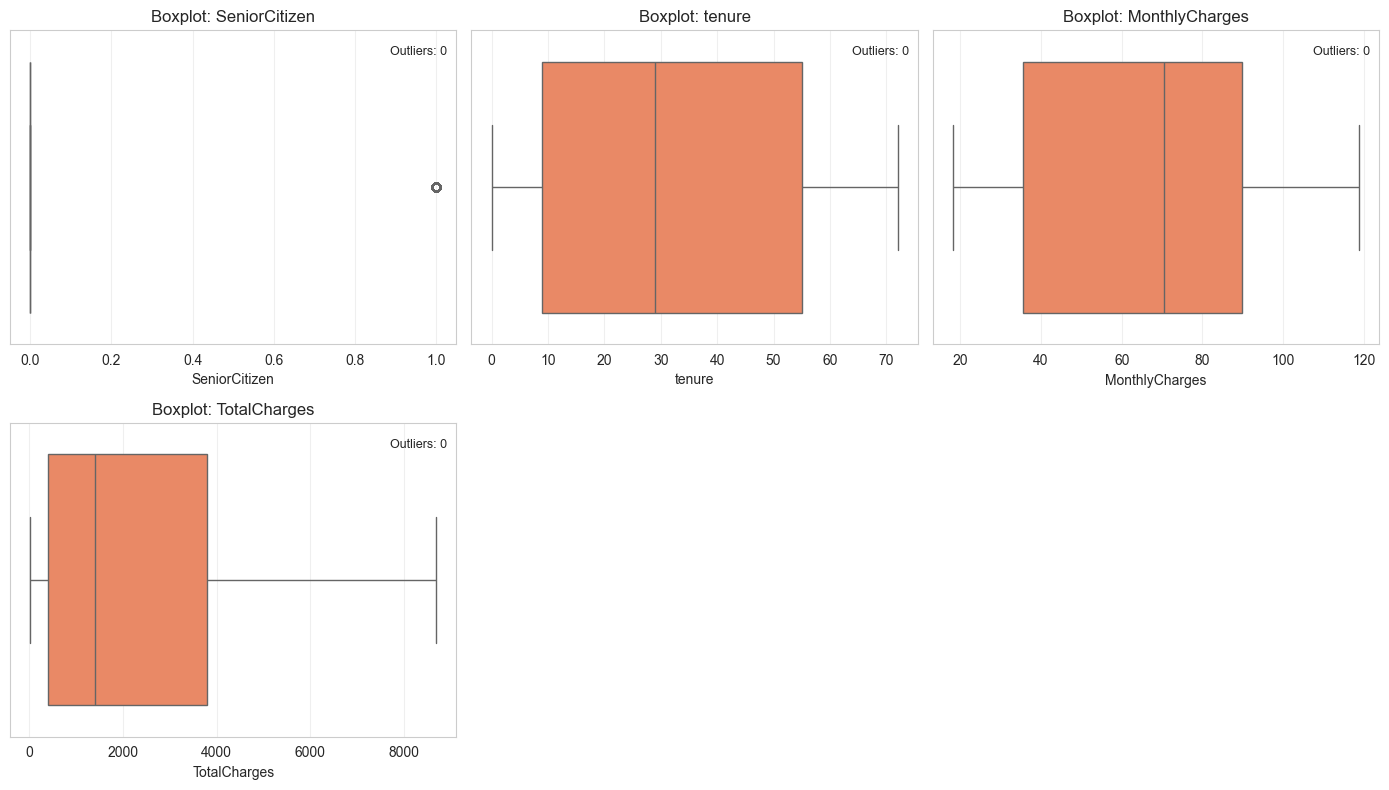

,coluna,outliers_zscore
0,SeniorCitizen,0
1,tenure,0
2,MonthlyCharges,0
3,TotalCharges,0


In [7]:
numeric_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != "Churn_bin"]

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).reshape(-1)

zscore_summary = []

for idx, col in enumerate(numeric_cols):
    series = df_eda[col].dropna()

    if sns is not None:
        sns.boxplot(x=series, ax=axes[idx], color="coral")
    else:
        axes[idx].boxplot(series, vert=False, patch_artist=True)

    axes[idx].set_title(f"Boxplot: {col}")
    axes[idx].grid(axis="x", alpha=0.3)

    if len(series) > 1 and float(series.std(ddof=0)) > 0:
        z_scores = np.abs((series - series.mean()) / series.std(ddof=0))
        outlier_count = int((z_scores > 3).sum())
    else:
        outlier_count = 0

    zscore_summary.append({"coluna": col, "outliers_zscore": outlier_count})
    axes[idx].text(
        0.98,
        0.95,
        f"Outliers: {outlier_count}",
        transform=axes[idx].transAxes,
        ha="right",
        va="top",
        fontsize=9,
    )

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

pd.DataFrame(zscore_summary).sort_values("outliers_zscore", ascending=False)

### 3.4 Análise de anomalias e duplicados

In [8]:
print("=== ANOMALIAS E CONSISTÊNCIA ===\n")
anomalies = []

tenure_invalid = df_eda[(df_eda["tenure"] < 0) | (df_eda["tenure"] > 120)]
if len(tenure_invalid) > 0:
    anomalies.append(f"tenure fora de 0-120: {len(tenure_invalid)}")

monthly_invalid = df_eda[df_eda["MonthlyCharges"] < 0]
if len(monthly_invalid) > 0:
    anomalies.append(f"MonthlyCharges negativo: {len(monthly_invalid)}")

total_invalid = df_eda[df_eda["TotalCharges"] < 0]
if len(total_invalid) > 0:
    anomalies.append(f"TotalCharges negativo: {len(total_invalid)}")

lower_total = df_eda[
    (df_eda["tenure"] > 1)
    & (df_eda["TotalCharges"].notna())
    & (df_eda["TotalCharges"] < df_eda["MonthlyCharges"])
]
if len(lower_total) > 0:
    anomalies.append(
        f"TotalCharges menor que MonthlyCharges para tenure>1: {len(lower_total)}"
    )

yes_no_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn",
]
for col in yes_no_cols:
    invalid = df_eda[~df_eda[col].isin(["Yes", "No"]) & df_eda[col].notna()]
    if len(invalid) > 0:
        anomalies.append(f"{col} com valor fora de Yes/No: {len(invalid)}")

if anomalies:
    print("Anomalias encontradas:")
    for item in anomalies:
        print(f"- {item}")
else:
    print("✓ Nenhuma anomalia crítica detectada nas validações de domínio.")

duplicates = int(df_eda.duplicated().sum())
print(f"\nRegistros duplicados: {duplicates}")

=== ANOMALIAS E CONSISTÊNCIA ===

✓ Nenhuma anomalia crítica detectada nas validações de domínio.

Registros duplicados: 0


### 3.5 Análise de distribuições

=== ASSIMETRIA (SKEWNESS) E CURTOSE ===



,Coluna,Skewness,Kurtosis,Interpretação
0,SeniorCitizen,1.834,1.363,Assimétrica à direita
1,tenure,0.240,-1.387,Normal
2,MonthlyCharges,-0.221,-1.257,Normal
3,TotalCharges,0.962,-0.232,Assimétrica à direita


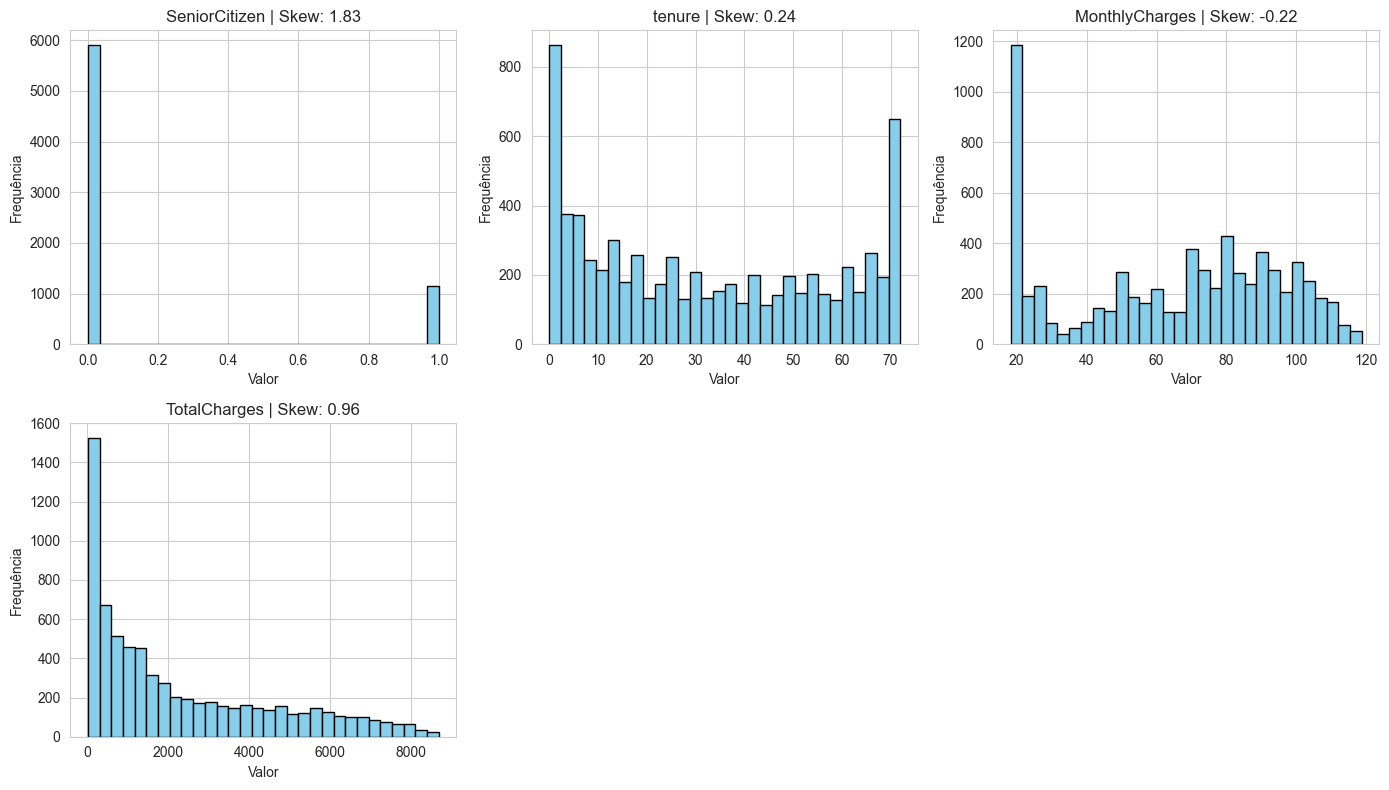

In [9]:
print("=== ASSIMETRIA (SKEWNESS) E CURTOSE ===\n")

distribution_stats = []
for col in numeric_cols:
    skewness = float(df_eda[col].skew())
    kurtosis = float(df_eda[col].kurtosis())
    distribution_stats.append(
        {
            "Coluna": col,
            "Skewness": round(skewness, 3),
            "Kurtosis": round(kurtosis, 3),
            "Interpretação": (
                "Normal"
                if abs(skewness) < 0.5
                else (
                    "Assimétrica à direita"
                    if skewness > 0
                    else "Assimétrica à esquerda"
                )
            ),
        }
    )

display(pd.DataFrame(distribution_stats))

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).reshape(-1)

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(
        df_eda[col].dropna(), bins=30, color="skyblue", edgecolor="black"
    )
    axes[idx].set_title(f"{col} | Skew: {df_eda[col].skew():.2f}")
    axes[idx].set_xlabel("Valor")
    axes[idx].set_ylabel("Frequência")

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### 3.6 Análise de correlações (data readiness)

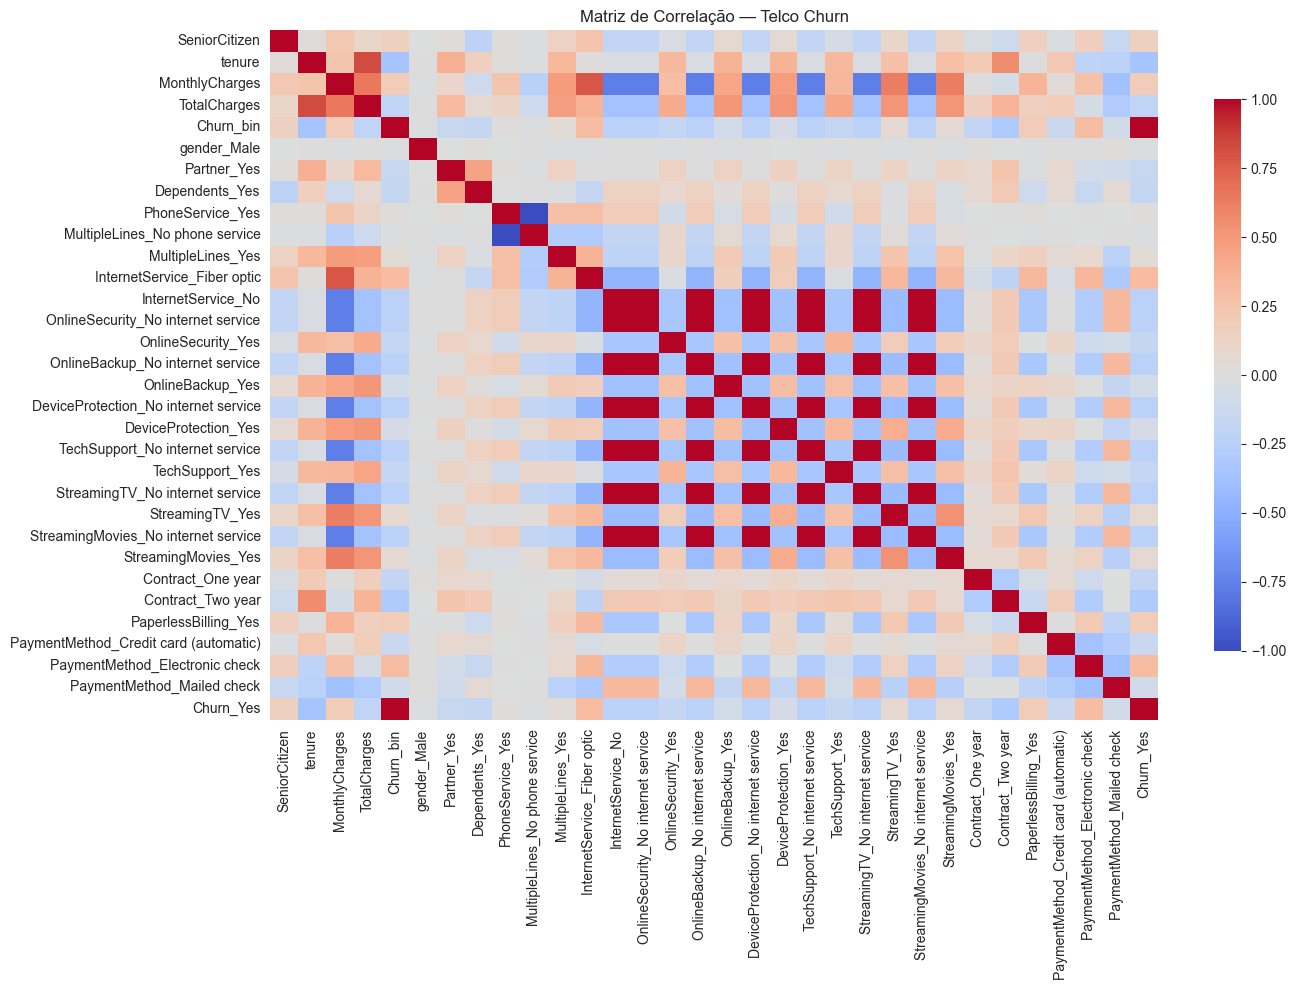

=== CORRELAÇÕES COM CHURN_BIN ===



Churn_bin                         1.000000
Churn_Yes                         1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling_Yes              0.191825
SeniorCitizen                     0.150889
StreamingTV_Yes                   0.063228
StreamingMovies_Yes               0.061382
MultipleLines_Yes                 0.040102
Name: Churn_bin, dtype: float64

TotalCharges                           -0.199484
OnlineSecurity_No internet service     -0.227890
StreamingMovies_No internet service    -0.227890
OnlineBackup_No internet service       -0.227890
InternetService_No                     -0.227890
TechSupport_No internet service        -0.227890
DeviceProtection_No internet service   -0.227890
StreamingTV_No internet service        -0.227890
Contract_Two year                      -0.302253
tenure                                 -0.352229
Name: Churn_bin, dtype: float64

=== POSSÍVEL MULTICOLINEARIDADE (|corr| > 0.7) ===



,Feature 1,Feature 2,Correlação
12,InternetService_No,DeviceProtection_No internet service,1.0
13,InternetService_No,TechSupport_No internet service,1.0
14,InternetService_No,StreamingTV_No internet service,1.0
11,InternetService_No,OnlineBackup_No internet service,1.0
10,InternetService_No,OnlineSecurity_No internet service,1.0
24,OnlineBackup_No internet service,StreamingMovies_No internet service,1.0
23,OnlineBackup_No internet service,StreamingTV_No internet service,1.0
22,OnlineBackup_No internet service,TechSupport_No internet service,1.0
21,OnlineBackup_No internet service,DeviceProtection_No internet service,1.0
20,OnlineSecurity_No internet service,StreamingMovies_No internet service,1.0


In [10]:
# Preparação para correlação com target binária
df_corr = df_eda.drop(columns=["customerID"]).copy()
df_corr = pd.get_dummies(df_corr, drop_first=True)
corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
if sns is not None:
    sns.heatmap(corr, cmap="coolwarm", center=0, cbar_kws={"shrink": 0.8})
else:
    plt.imshow(corr, cmap="coolwarm", aspect="auto")
    plt.colorbar(shrink=0.8)
    plt.xticks([])
    plt.yticks([])
plt.title("Matriz de Correlação — Telco Churn")
plt.tight_layout()
plt.show()

print("=== CORRELAÇÕES COM CHURN_BIN ===\n")
target_corr = corr["Churn_bin"].sort_values(ascending=False)
display(target_corr.head(10))
display(target_corr.tail(10))

print("=== POSSÍVEL MULTICOLINEARIDADE (|corr| > 0.7) ===\n")
high_pairs = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        value = float(corr.iloc[i, j])
        if (
            abs(value) > 0.7
            and cols[i] != "Churn_bin"
            and cols[j] != "Churn_bin"
        ):
            high_pairs.append((cols[i], cols[j], round(value, 3)))

if high_pairs:
    multicol_df = pd.DataFrame(
        high_pairs, columns=["Feature 1", "Feature 2", "Correlação"]
    )
    display(multicol_df.sort_values("Correlação", ascending=False).head(20))
else:
    print(
        "✓ Nenhuma correlação forte detectada entre features (excluindo target)."
    )

## 4. Encerramento da análise

### Resumo da análise
- O dataset possui **7043 registros e 21 colunas**, com boa consistência estrutural para modelagem.
- Foi identificado baixo volume de valores ausentes, concentrado em `TotalCharges` (11 casos), já tratado na preparação para EDA.
- A variável alvo `Churn` está desbalanceada (ratio ~0.36), o que reforça a necessidade de avaliar métricas além de acurácia.
- As análises de correlação e distribuição indicam sinais relevantes de churn ligados a perfil de contrato, tempo de permanência e padrão de cobrança.